In [1]:
import snag
import qse
import numpy as np
import matplotlib.pyplot as plt

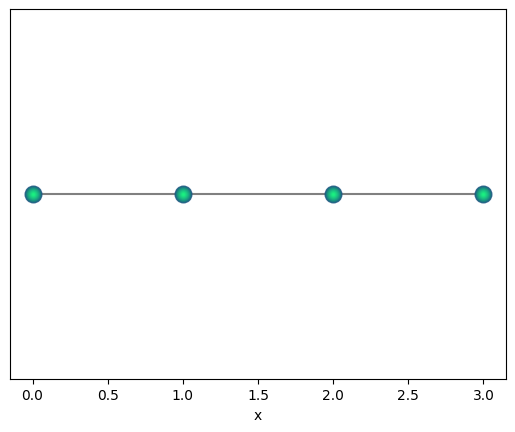

In [2]:
n_sites = 4
qbits = qse.lattices.chain(1.0, n_sites)
qbits.draw(radius="nearest")

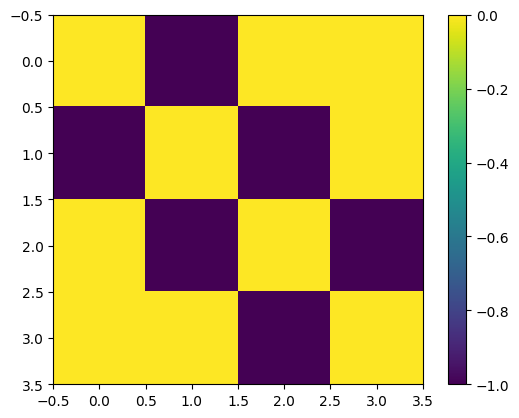

In [3]:
t_mat = -qbits.get_adjacency_matrix(1.0)
plt.imshow(t_mat)
plt.colorbar()
plt.show()

In [22]:
calc = snag.Hubbard(n_up=2, n_dn=0, n_sites=qbits.nqbits)
print(calc.basis)

h_t = calc.hopping(t_mat)
h_u = calc.n_up_n_dn()

hamiltonian = h_t + h_u * 1.0

print(h_u)

initial_state = np.zeros(calc.dim)
initial_state[3] = 1.0
print(initial_state)

[[[1 1 0 0]
  [0 0 0 0]]

 [[1 0 1 0]
  [0 0 0 0]]

 [[1 0 0 1]
  [0 0 0 0]]

 [[0 1 1 0]
  [0 0 0 0]]

 [[0 1 0 1]
  [0 0 0 0]]

 [[0 0 1 1]
  [0 0 0 0]]]
[0 0 0 0 0 0]
[0. 0. 0. 1. 0. 0.]


In [26]:
results = qse.calc.evolve(hamiltonian, 1.0, 10, initial_state=initial_state)
print(results)

[[ 0.        +0.j          0.        +0.j          0.        +0.j
   1.        +0.j          0.        +0.j          0.        +0.j        ]
 [-0.0049792 +0.j          0.        +0.09916875j -0.0099584 +0.j
   0.9900416 +0.j          0.        +0.09916875j -0.0049792 +0.j        ]
 [-0.01966888+0.j          0.        +0.19339968j -0.03933776+0.j
   0.96066224+0.j          0.        +0.19339968j -0.01966888+0.j        ]
 [-0.04333761+0.j          0.        +0.27800086j -0.08667522+0.j
   0.91332478+0.j          0.        +0.27800086j -0.04333761+0.j        ]
 [-0.07480688+0.j          0.        +0.34875981j -0.14961375+0.j
   0.85038625+0.j          0.        +0.34875981j -0.07480688+0.j        ]
 [-0.11250976+0.j          0.        +0.40215331j -0.22501952+0.j
   0.77498048+0.j          0.        +0.40215331j -0.11250976+0.j        ]
 [-0.15456896+0.j          0.        +0.43552279j -0.30913791+0.j
   0.69086209+0.j          0.        +0.43552279j -0.15456896+0.j        ]
 [-0.19889026

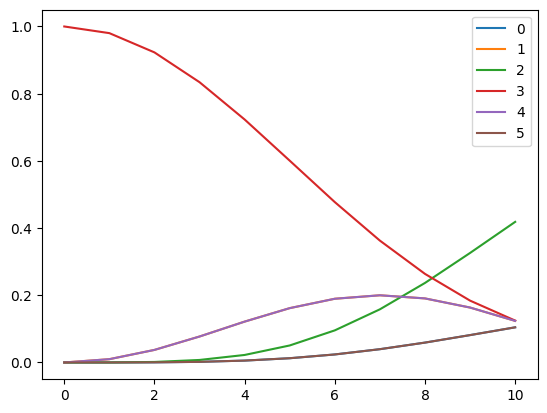

In [28]:
probs = (np.conj(results) * results).real

for i in range(calc.dim):
    plt.plot(probs[:, i], label=i)

plt.legend()
plt.show()

In [ ]:
n_part = n_sites // 2

spin = []
energy = []

for n_dn in range(n_part + 1):
    e = calc.total_energy(n_part - n_dn, n_dn)
    spin.append((n_part - 2 * n_dn))
    energy.append(e)

In [ ]:
plt.plot(spin, energy, marker="o")
plt.show()